In [1]:
import argparse
import os
import torch
import torch.backends
import matplotlib.pyplot as plt
from exp.exp_long_term_forecasting import Exp_Long_Term_Forecast
from exp.exp_quantile import Exp_Quantile
from utils.print_args import print_args
import random
import numpy as np
import shutil
%matplotlib inline

In [ ]:
fix_seed = 2026
random.seed(fix_seed)
torch.manual_seed(fix_seed)
np.random.seed(fix_seed)

parser = argparse.ArgumentParser(description='TimesNet')

# basic config
parser.add_argument('--is_training', type=int, required=False, default=1, help='status')
parser.add_argument('--model_id', type=str, required=False, default='test', help='model id')
parser.add_argument('--model', type=str, required=False, default='Autoformer',
                    help='model name, options: [Autoformer, Transformer, TimesNet]')

# data loader
parser.add_argument('--data', type=str, required=False, default='ETTh1', help='dataset type')
parser.add_argument('--root_path', type=str, default='./datasets/', help='root path of the data file')
parser.add_argument('--data_path', type=str, default='Reactor1.csv', help='data file')
parser.add_argument('--features', type=str, default='M',
                        help='forecasting task, options:[M, S, MS]; M:multivariate predict multivariate, S:univariate predict univariate, MS:multivariate predict univariate')
parser.add_argument('--target', type=str, default='OT', help='target feature in S or MS task')
parser.add_argument('--freq', type=str, default='h',
                    help='freq for time features encoding, options:[s:secondly, t:minutely, h:hourly, d:daily, b:business days, w:weekly, m:monthly], you can also use more detailed freq like 15min or 3h')
parser.add_argument('--checkpoints', type=str, default='./checkpoints/', help='location of model checkpoints')

# forecasting task
parser.add_argument('--seq_len', type=int, default=96, help='input sequence length')
parser.add_argument('--label_len', type=int, default=48, help='start token length')
parser.add_argument('--pred_len', type=int, default=96, help='prediction sequence length')
parser.add_argument('--seasonal_patterns', type=str, default='Monthly', help='subset for M4')
parser.add_argument('--inverse', action='store_true', help='inverse output data', default=False)

_StoreTrueAction(option_strings=['--inverse'], dest='inverse', nargs=0, const=True, default=False, type=None, choices=None, required=False, help='inverse output data', metavar=None)

In [3]:
# model define
parser.add_argument('--expand', type=int, default=2, help='expansion factor for Mamba')
parser.add_argument('--d_conv', type=int, default=4, help='conv kernel size for Mamba')
parser.add_argument('--top_k', type=int, default=5, help='for TimesBlock')
parser.add_argument('--num_kernels', type=int, default=6, help='for Inception')
parser.add_argument('--enc_in', type=int, default=7, help='encoder input size')
parser.add_argument('--dec_in', type=int, default=7, help='decoder input size')
parser.add_argument('--c_out', type=int, default=7, help='output size')
parser.add_argument('--d_model', type=int, default=512, help='dimension of model')
parser.add_argument('--n_heads', type=int, default=8, help='num of heads')
parser.add_argument('--e_layers', type=int, default=2, help='num of encoder layers')
parser.add_argument('--d_layers', type=int, default=1, help='num of decoder layers')
parser.add_argument('--d_ff', type=int, default=2048, help='dimension of fcn')
parser.add_argument('--moving_avg', type=int, default=25, help='window size of moving average')
parser.add_argument('--factor', type=int, default=1, help='attn factor')
parser.add_argument('--distil', action='store_false',
                    help='whether to use distilling in encoder, using this argument means not using distilling',
                    default=True)
parser.add_argument('--dropout', type=float, default=0.1, help='dropout')
parser.add_argument('--embed', type=str, default='timeF',
                    help='time features encoding, options:[timeF, fixed, learned]')
parser.add_argument('--activation', type=str, default='gelu', help='activation')
parser.add_argument('--channel_independence', type=int, default=1,
                    help='0: channel dependence 1: channel independence for FreTS model')
parser.add_argument('--decomp_method', type=str, default='moving_avg',
                    help='method of series decompsition, only support moving_avg or dft_decomp')
parser.add_argument('--use_norm', type=int, default=1, help='whether to use normalize; True 1 False 0')
parser.add_argument('--down_sampling_layers', type=int, default=0, help='num of down sampling layers')
parser.add_argument('--down_sampling_window', type=int, default=1, help='down sampling window size')
parser.add_argument('--down_sampling_method', type=str, default=None,
                    help='down sampling method, only support avg, max, conv')
parser.add_argument('--seg_len', type=int, default=96,
                    help='the length of segmen-wise iteration of SegRNN')

_StoreAction(option_strings=['--seg_len'], dest='seg_len', nargs=None, const=None, default=96, type=<class 'int'>, choices=None, required=False, help='the length of segmen-wise iteration of SegRNN', metavar=None)

In [4]:
# optimization
parser.add_argument('--num_workers', type=int, default=10, help='data loader num workers')
parser.add_argument('--itr', type=int, default=1, help='experiments times')
parser.add_argument('--train_epochs', type=int, default=10, help='train epochs')
parser.add_argument('--batch_size', type=int, default=32, help='batch size of train input data')
parser.add_argument('--patience', type=int, default=3, help='early stopping patience')
parser.add_argument('--learning_rate', type=float, default=0.0001, help='optimizer learning rate')
parser.add_argument('--des', type=str, default='test', help='exp description')
parser.add_argument('--loss', type=str, default='MSE', help='loss function')
parser.add_argument('--lradj', type=str, default='type1', help='adjust learning rate')
parser.add_argument('--use_amp', action='store_true', help='use automatic mixed precision training', default=False)

# GPU
parser.add_argument('--use_gpu', type=bool, default=True, help='use gpu')
parser.add_argument('--gpu', type=int, default=0, help='gpu')
parser.add_argument('--gpu_type', type=str, default='cuda', help='gpu type')  # cuda or mps
parser.add_argument('--use_multi_gpu', action='store_true', help='use multiple gpus', default=False)
parser.add_argument('--devices', type=str, default='0,1,2,3', help='device ids of multile gpus')


_StoreAction(option_strings=['--devices'], dest='devices', nargs=None, const=None, default='0,1,2,3', type=<class 'str'>, choices=None, required=False, help='device ids of multile gpus', metavar=None)

In [5]:
# de-stationary projector params
parser.add_argument('--p_hidden_dims', type=int, nargs='+', default=[128, 128],
                    help='hidden layer dimensions of projector (List)')
parser.add_argument('--p_hidden_layers', type=int, default=2, help='number of hidden layers in projector')

# metrics (dtw)
parser.add_argument('--use_dtw', type=bool, default=True,
                    help='the controller of using dtw metric (dtw is time consuming, not suggested unless necessary)')

# Augmentation
parser.add_argument('--augmentation_ratio', type=int, default=0, help="How many times to augment")
parser.add_argument('--seed', type=int, default=2, help="Randomization seed")
parser.add_argument('--jitter', default=False, action="store_true", help="Jitter preset augmentation")
parser.add_argument('--scaling', default=False, action="store_true", help="Scaling preset augmentation")
parser.add_argument('--permutation', default=False, action="store_true",
                    help="Equal Length Permutation preset augmentation")
parser.add_argument('--randompermutation', default=False, action="store_true",
                    help="Random Length Permutation preset augmentation")
parser.add_argument('--magwarp', default=False, action="store_true", help="Magnitude warp preset augmentation")
parser.add_argument('--timewarp', default=False, action="store_true", help="Time warp preset augmentation")
parser.add_argument('--windowslice', default=False, action="store_true", help="Window slice preset augmentation")
parser.add_argument('--windowwarp', default=False, action="store_true", help="Window warp preset augmentation")
parser.add_argument('--rotation', default=False, action="store_true", help="Rotation preset augmentation")
parser.add_argument('--spawner', default=False, action="store_true", help="SPAWNER preset augmentation")
parser.add_argument('--dtwwarp', default=False, action="store_true", help="DTW warp preset augmentation")
parser.add_argument('--shapedtwwarp', default=False, action="store_true", help="Shape DTW warp preset augmentation")
parser.add_argument('--wdba', default=False, action="store_true", help="Weighted DBA preset augmentation")
parser.add_argument('--discdtw', default=False, action="store_true",
                    help="Discrimitive DTW warp preset augmentation")
parser.add_argument('--discsdtw', default=False, action="store_true",
                    help="Discrimitive shapeDTW warp preset augmentation")
parser.add_argument('--extra_tag', type=str, default="", help="Anything extra")


_StoreAction(option_strings=['--extra_tag'], dest='extra_tag', nargs=None, const=None, default='', type=<class 'str'>, choices=None, required=False, help='Anything extra', metavar=None)

In [6]:
# TimeXer
parser.add_argument('--patch_len', type=int, default=16, help='patch length')

# GCN
parser.add_argument('--node_dim', type=int, default=10, help='each node embbed to dim dimentions')
parser.add_argument('--gcn_depth', type=int, default=2, help='')
parser.add_argument('--gcn_dropout', type=float, default=0.3, help='')
parser.add_argument('--propalpha', type=float, default=0.3, help='')
parser.add_argument('--conv_channel', type=int, default=32, help='')
parser.add_argument('--skip_channel', type=int, default=32, help='')

parser.add_argument('--individual', action='store_true', default=False,
                    help='DLinear: a linear layer for each variate(channel) individually')

# TimeFilter
parser.add_argument('--alpha', type=float, default=0.1, help='KNN for Graph Construction')
parser.add_argument('--top_p', type=float, default=0.5, help='Dynamic Routing in MoE')
parser.add_argument('--pos', type=int, choices=[0, 1], default=1, help='Positional Embedding. Set pos to 0 or 1')

_StoreAction(option_strings=['--pos'], dest='pos', nargs=None, const=None, default=1, type=<class 'int'>, choices=[0, 1], required=False, help='Positional Embedding. Set pos to 0 or 1', metavar=None)

In [7]:
parser.add_argument('--save_results_data', type=int, default=1, help='Save trues and preds for further analysis')

_StoreAction(option_strings=['--save_results_data'], dest='save_results_data', nargs=None, const=None, default=1, type=<class 'int'>, choices=None, required=False, help='Save trues and preds for further analysis', metavar=None)

In [8]:
parser.add_argument('--quantile', type=float, default=0.95, help='Quatile regression')
parser.add_argument('--quantile_tau', type=float, default=0.0, help='Quatile regression')

_StoreAction(option_strings=['--quantile_tau'], dest='quantile_tau', nargs=None, const=None, default=0.0, type=<class 'float'>, choices=None, required=False, help='Quatile regression', metavar=None)

In [9]:
args = parser.parse_args(
    ['--is_training', '1', 
     '--root_path', './datasets/', 
     '--data_path', 'reactor1.csv', 
     '--model_id', 'test2', 
     '--save_results_data', '1',
     '--target', 'A1',
     '--freq', 'h',
     '--inverse', 
     '--top_k', '5',
     '--train_epochs', '5',
     '--batch_size', '16',
     '--loss', 'MSE',
     '--model', 'TCN', 
     '--data', 'custom', 
     '--features', 'MS',
     '--seq_len', '12', 
     '--label_len', '3', 
     '--pred_len', '6', 
     '--e_layers', '1', 
     '--d_layers', '1', 
     '--n_heads', '4',
     '--factor','6',
     '--enc_in', '6', 
     '--dec_in', '6', 
     '--c_out', '6',
     '--des', 'Exp', 
     '--d_model', '256', 
     '--d_ff', '512',
     '--itr', '1'])

In [10]:
if torch.cuda.is_available() and args.use_gpu:
    args.device = torch.device('cuda:{}'.format(args.gpu))
    print('Using GPU')
else:
    if hasattr(torch.backends, "mps"):
        args.device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
    else:
        args.device = torch.device("cpu")
    print('Using cpu or mps')

if args.use_gpu and args.use_multi_gpu:
    args.devices = args.devices.replace(' ', '')
    device_ids = args.devices.split(',')
    args.device_ids = [int(id_) for id_ in device_ids]
    args.gpu = args.device_ids[0]

print('Args in experiment:')
print_args(args)

Exp = Exp_Long_Term_Forecast


Using GPU
Args in experiment:
Basic Config
  Is Training:        1                   
  Model ID:           test2               Model:              TCN                 

Data Loader
  Data:               custom              Root Path:          ./datasets/         
  Data Path:          reactor1.csv        Features:           MS                  
  Target:             A1                  Freq:               h                   
  Checkpoints:        ./checkpoints/      

Forecasting Task
  Seq Len:            12                  Label Len:          3                   
  Pred Len:           6                   Seasonal Patterns:  Monthly             
  Inverse:            1                   

Model Parameters
  Top k:              5                   Num Kernels:        6                   
  Enc In:             6                   Dec In:             6                   
  C Out:              6                   d model:            256                 
  n heads:            4         

Use GPU: cuda:0
>>>>>>>start training : test2_TCN_custom_ftMS_sl12_ll3_pl6_dm256_nh4_el1_dl1_df512_expand2_dc4_fc6_ebtimeF_dtTrue_Exp_0>>>>>>>>>>>>>>>>>>>>>>>>>>
train 1814
val 388
test 387
Epoch: 1 cost time: 1.1478288173675537
Epoch: 1 | Train Loss: 0.1612846 Vali Loss: 0.0842432 Test Loss: 0.0812756
Validation loss decreased (inf --> 0.084243).  Saving model ...
Updating learning rate to 0.0001
>>>>-----------------------------------Separator line-----------------------------------<<<<
Epoch: 2 cost time: 0.876267671585083
Epoch: 2 | Train Loss: 0.0888718 Vali Loss: 0.0693187 Test Loss: 0.0753173
Validation loss decreased (0.084243 --> 0.069319).  Saving model ...
Updating learning rate to 5e-05
>>>>-----------------------------------Separator line-----------------------------------<<<<
Epoch: 3 cost time: 0.8499319553375244
Epoch: 3 | Train Loss: 0.0748991 Vali Loss: 0.0777717 Test Loss: 0.1036965
EarlyStopping counter: 1 out of 3
Updating learning rate to 2.5e-05
>>>>-------------

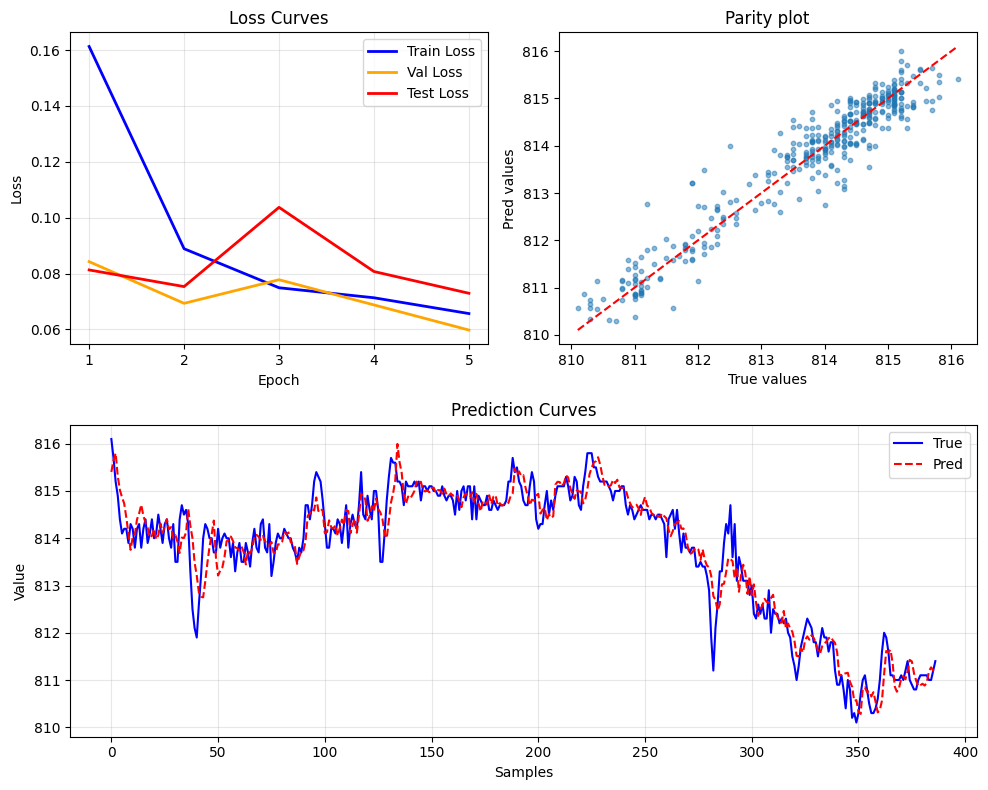

>>>>-----------------------------------Diebold Mariano Test-----------------------------------<<<<
Diebold-Mariano statistic: 1.208857, P value: 0.886641.
The test2 model is worse than TCN.


In [11]:
if args.is_training:
    for ii in range(args.itr): # itrs with different random seeds (optional, default 1)
        # setting record of experiments
        exp = Exp(args)  # set experiments
        setting = '{}_{}_{}_ft{}_sl{}_ll{}_pl{}_dm{}_nh{}_el{}_dl{}_df{}_expand{}_dc{}_fc{}_eb{}_dt{}_{}_{}'.format(
            args.model_id,
            args.model,
            args.data,
            args.features,
            args.seq_len,
            args.label_len,
            args.pred_len,
            args.d_model,
            args.n_heads,
            args.e_layers,
            args.d_layers,
            args.d_ff,
            args.expand,
            args.d_conv,
            args.factor,
            args.embed,
            args.distil,
            args.des, ii)

        print('>>>>>>>start training : {}>>>>>>>>>>>>>>>>>>>>>>>>>>'.format(setting))
        exp.train(setting)

        print('>>>>>>>testing : {}<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<'.format(setting))
        exp.test(setting)
        if args.gpu_type == 'mps':
            torch.backends.mps.empty_cache()
        elif args.gpu_type == 'cuda':
            torch.cuda.empty_cache()
else:
    exp = Exp(args)  # set experiments
    ii = 0
    setting = '{}_{}_{}_ft{}_sl{}_ll{}_pl{}_dm{}_nh{}_el{}_dl{}_df{}_expand{}_dc{}_fc{}_eb{}_dt{}_{}_{}'.format(
        args.model_id,
        args.model,
        args.data,
        args.features,
        args.seq_len,
        args.label_len,
        args.pred_len,
        args.d_model,
        args.n_heads,
        args.e_layers,
        args.d_layers,
        args.d_ff,
        args.expand,
        args.d_conv,
        args.factor,
        args.embed,
        args.distil,
        args.des, ii)

    print('>>>>>>>testing : {}<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<'.format(setting))
    exp.test(setting, test=1)
    if args.gpu_type == 'mps':
        torch.backends.mps.empty_cache()
    elif args.gpu_type == 'cuda':
        torch.cuda.empty_cache()
    

In [12]:
shutil.rmtree('./checkpoints') 
os.makedirs('./checkpoints', exist_ok=True)

[0.025, 0.975]
Use GPU: cuda:0
It's lower quantile, quantile is 0.025.
train 1814
val 388
test 387
It's Quantile regression
This is 0.025
Epoch: 1 | Train Loss: 0.0266758 Vali Loss: 0.0206237 Test Loss: 0.0233681
Validation loss decreased (inf --> 0.020624).  Saving model ...
Updating learning rate to 0.0001
>>>>-----------------------------------Separator line-----------------------------------<<<<
Epoch: 2 | Train Loss: 0.0187378 Vali Loss: 0.0198979 Test Loss: 0.0229655
Validation loss decreased (0.020624 --> 0.019898).  Saving model ...
Updating learning rate to 5e-05
>>>>-----------------------------------Separator line-----------------------------------<<<<
Epoch: 3 | Train Loss: 0.0175939 Vali Loss: 0.0192917 Test Loss: 0.0231839
Validation loss decreased (0.019898 --> 0.019292).  Saving model ...
Updating learning rate to 2.5e-05
>>>>-----------------------------------Separator line-----------------------------------<<<<
Epoch: 4 | Train Loss: 0.0169404 Vali Loss: 0.0194351 Tes

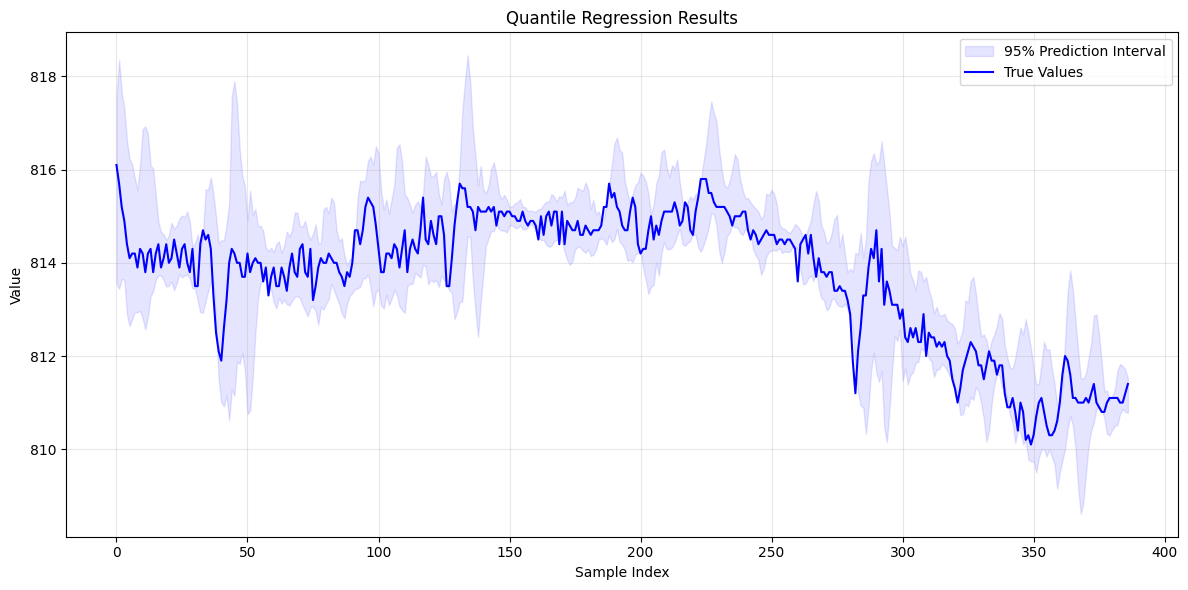

PICP: 89.922, ACE: -5.078, MPIW: 1.848, PINAW: 0.308


In [13]:
if args.quantile > 0:
    quantile_list = [round((1-args.quantile)*0.5, 3), round(args.quantile + (1-args.quantile)*0.5, 3)]
    print(quantile_list)
    qExp = Exp_Quantile
    exp = qExp(args)

for j in range(2):
    #args = parser.parse_args(['--quantile_tau', str(quantile_list[j])])
    exp.args.quantile_tau = quantile_list[j]

    if j == 0:
        print(f"It's lower quantile, quantile is {args.quantile_tau}.")
    else:
        print(f"It's upper quantile, quantile is {args.quantile_tau}.")

    exp.train(setting)
    exp.test(setting)
    if args.gpu_type == 'mps':
        torch.backends.mps.empty_cache()
    elif args.gpu_type == 'cuda':
        torch.cuda.empty_cache()

